In [1]:
%load_ext autoreload
%autoreload 2

import os, sys

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

In [7]:
from progsnap2.datasets import cs1eng, codeworkout

# Select a dataset by setting the config variable
config = cs1eng.S24
# config = codeworkout.F19


dataset_name, dataset_semester = config.name.split('_')
dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)
dataset = config.load(dataset_root_dir)

In [8]:
# Just get the first few thousand rows for testing and quicker loading
sample_size = 10000
main_table_sample = dataset.get_main_table_head(sample_size)
# main_table_sample

In [9]:
most_common_problem = main_table_sample[Cols.ProblemID].value_counts().idxmax()
most_common_problem

'inlab2'

In [10]:
problem_subset = main_table_sample[main_table_sample[Cols.ProblemID] == most_common_problem]
problem_subset[Cols.SubjectID].nunique()

18

In [14]:
problem_codestates = dataset.get_codestates(problem_subset)
problem_codestates.head()

,CodeStateID,Code
0,5508,"""""""\r\n Author: [**********************]\r\..."
1,5508,"""""""\r\n Author: [**********************]\r\..."
2,5508,"""""""\r\n Author: [**********************]\r\..."
3,5508,"""""""\r\n Author: [**********************]\r\..."
4,5554,"""""""\r\n Author: [**********************]\r\..."


In [15]:
logs_with_code = pd.merge(
    problem_subset,
    problem_codestates,
    on=Cols.CodeStateID,
)

In [10]:
from progsnap2.analytics.analytics_config import ProgrammingLanguage
from progsnap2.analytics.code.python.clean import CleanPythonPreprocessor
from progsnap2.spec.enums import CodeStatesTableColumns as CodeCols

if config.programming_language == ProgrammingLanguage.Python:
    cleaner = CleanPythonPreprocessor()

    cleaned_codestates = cleaner.fit_transform(logs_with_code[CodeCols.Code])
    for i in range(2):
        print(f"Original:\n{logs_with_code.iloc[i][CodeCols.Code]}")
        print(f"Cleaned:\n{cleaned_codestates[i]}")
        print()
else:
    print("No cleaner available for this programming language.")
    cleaned_codestates = logs_with_code[CodeCols.Code]

No cleaner available for this programming language.


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
token_pattern = r"[\w]+|[^\s]|[ ]{4}"
ngram_range = (1,3)
vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=token_pattern,
    ngram_range=ngram_range
)

X = vectorizer.fit_transform(cleaned_codestates)
X.shape

(1809, 1392)

In [12]:
# Convert to 2D using TSNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X.toarray())
X_tsne

array([[-65.49016 , -19.27982 ],
       [-65.49016 , -19.27982 ],
       [-65.49016 , -19.27982 ],
       ...,
       [ 90.70181 ,  33.924835],
       [ 90.70181 ,  33.924835],
       [ 90.70181 ,  33.924835]], shape=(1809, 2), dtype=float32)

<Axes: >

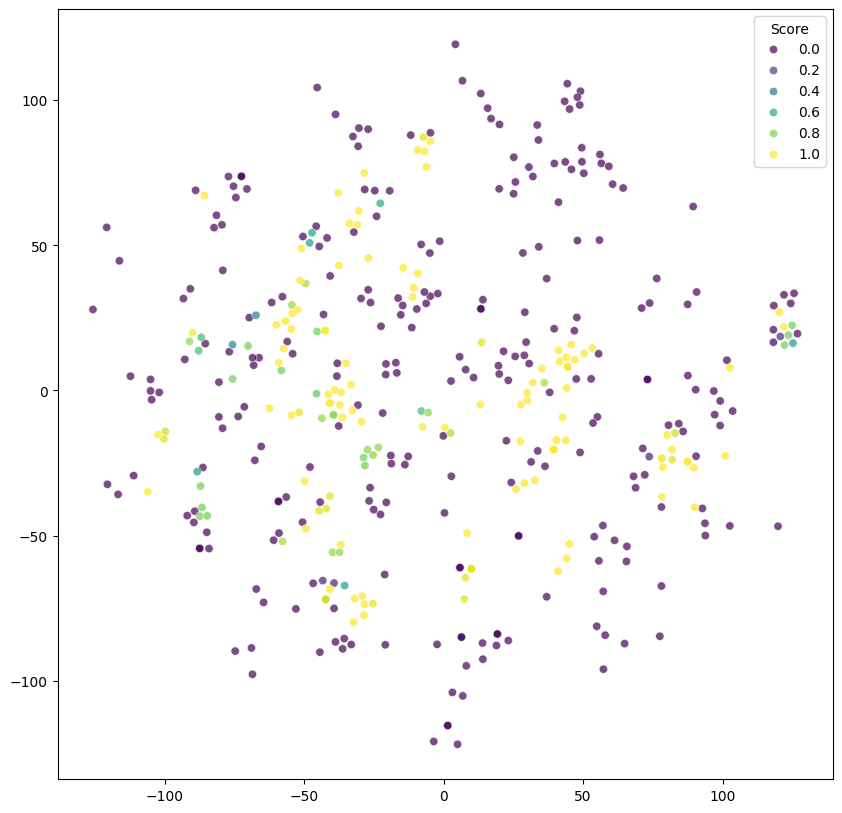

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=logs_with_code[Cols.Score], palette='viridis', alpha=0.7)